# Audio Processing Using Mel-Spectrograms 

A Mel-Spectrogram is a 2D heatmap that visualizes audio by showing **Time** vs **Frequency (Pitch)** vs **Volume (Color)**. 

Unlike standard waveforms, it displays audio exactly the way the human brain physically perceives and processes it.

## Core Concepts 

* **Amplitude & Intensity:** Amplitude is the physical height of the waveform. The higher the wave, the more intense the energy. Our brains perceive this physical intensity as *loudness*.

* **Logarithmic Human Hearing:** Human hearing is not linear; it is logarithmic. 
  * A difference of **100 Hz** at the low end example, 100 Hz -> 200 Hz is highly audible to the human ear.
  * However, that exact same mathematical difference at the high end (e.g., 10,000 Hz -> 10,100 Hz) sounds completely identical to us. The Mel Scale accounts for this biological quirk.

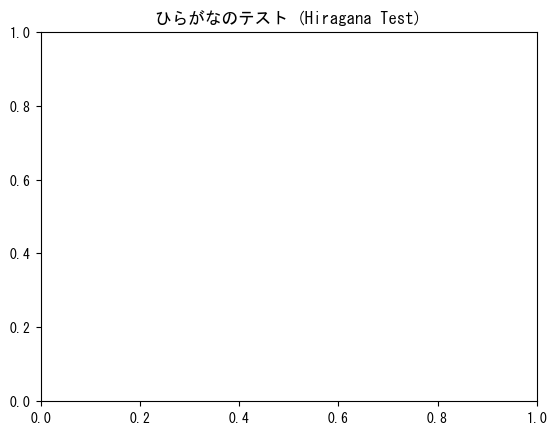

In [39]:
# Imports
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# Use 'MS Gothic' for Windows, 'AppleGothic' for Mac, or 'Noto Sans CJK JP' for Linux
plt.rcParams['font.family'] = 'MS Gothic' 

# Quick Test
plt.title("ひらがなのテスト (Hiragana Test)")
plt.show()

# Data and folder Setup

In [40]:
# Environment Setup
audio_dir = "../ojad_audio/"

# Search the directory and grab ONLY files ending in .mp3
audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]

print(f"Data Check: Found {len(audio_files)} MP3 files ready for processing.")
# check first file
if audio_files:
    print(f"Sample target: {audio_files[0]}")

Data Check: Found 300 MP3 files ready for processing.
Sample target: 1001_見下ろす_miorosu_female_Nakadaka.mp3


# Transformation Logic

Sample Rate: sr = 22050hz is enough for standard human speech

Mel - Spectogram - the Audio is chopped into tiny slices of time called windows 
    And Analyzes the volume of 128 different frequency bands (y-axis)

Decibels - Neural networks learn better when data mimics human perception

Human hearing is logarithmic, 

In [ ]:
# Audio Processor Function
def mp3_to_mel_spectrogram(file_path):
    """
    Translates an MP3 file into a 2D mathematical Mel-Spectrogram matrix.
    Returns: A NumPy array representing the audio.
    """
    # Load the audio. 
    # audio_signal is a 1D array of the actual sound waves.
    audio_signal, sample_rate = librosa.load(file_path, sr=22050)
    
    # Perform the Fourier Transform to get frequencies
    mel_spec = librosa.feature.melspectrogram(
        y=audio_signal, 
        sr=sample_rate, 
        n_mels=128,  # 128 rows of frequency data (the Y-axis)
        fmax=8000    # Human speech pitch rarely goes above 8000Hz, cropped the high end static
    )
    
    # Convert the raw energy into a Logarithmic scale (Decibels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    return mel_spec_db, sample_rate

print("Audio processing ready")

Audio processing ready


# Visualising the three pitch accent types

Found 3 different pitch types to visualize

--- VISUAL FOR: 1053_開く_hiraku_female_Heiban.mp3 ---
Matrix Shape: (128, 35)
Audio Time Slices: 35


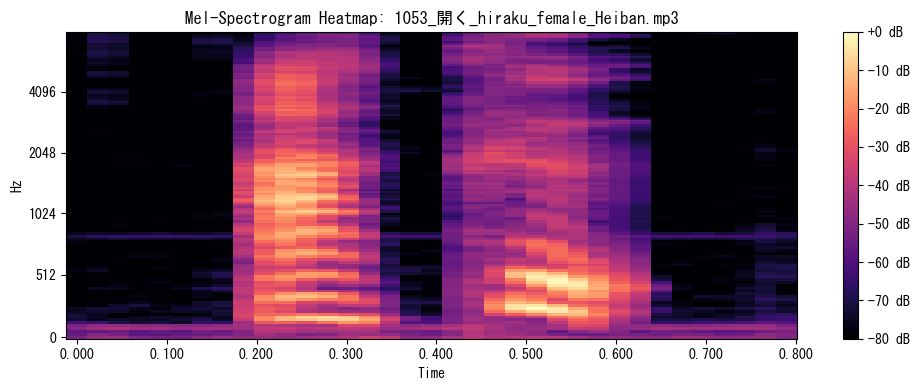


--- VISUAL FOR: 113_打つ_utsu_female_Atamadaka.mp3 ---
Matrix Shape: (128, 34)
Audio Time Slices: 34


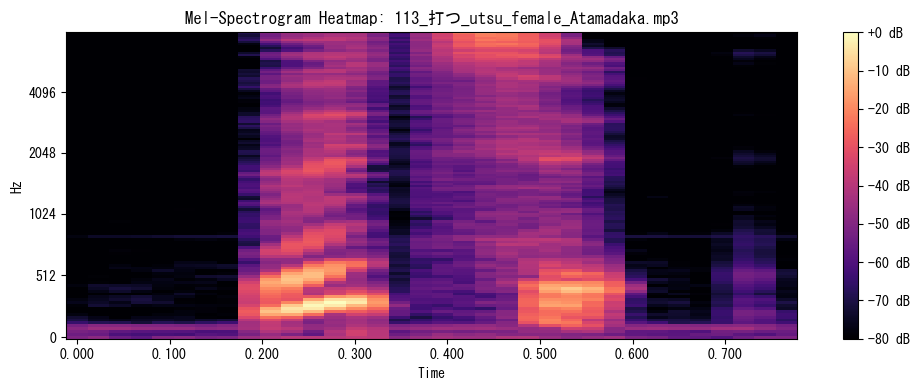


--- VISUAL FOR: 1001_見下ろす_miorosu_female_Nakadaka.mp3 ---
Matrix Shape: (128, 45)
Audio Time Slices: 45


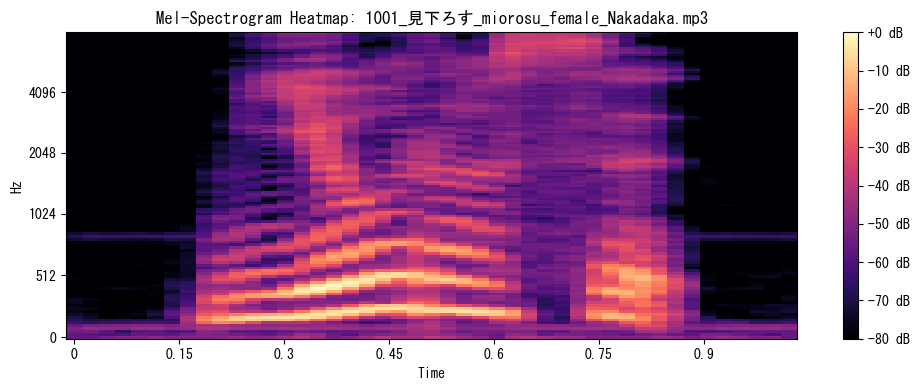

In [42]:
# Show a visualion of each pitch
target_categories = ["Heiban", "Atamadaka", "Nakadaka"]
files_to_test = []

# Loop through to find one of each category
for target in target_categories:
    for filename in audio_files:
        if target in filename:
            files_to_test.append(filename)
            break # break after finding one

print(f"Found {len(files_to_test)} different pitch types to visualize")

# --- VISUALS --- 
if len(files_to_test) > 0:
    for test_file in files_to_test:
        test_path = os.path.join(audio_dir, test_file)
        
        try:
            # Run function on the file
            test_matrix, test_sr = mp3_to_mel_spectrogram(test_path)
            
            print(f"\n--- VISUAL FOR: {test_file} ---")
            print(f"Matrix Shape: {test_matrix.shape}")
            print(f"Audio Time Slices: {test_matrix.shape[1]}")
            
            # Draw the Heatmap
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(test_matrix, x_axis='time', y_axis='mel', sr=test_sr, fmax=8000)
            plt.colorbar(format='%+2.0f dB')
            plt.title(f'Mel-Spectrogram Heatmap: {test_file}')
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Couldn't draw {test_file}: {e}")

# Save all Audio Files as Mel Spectograms .npy to use for training

In [ ]:
"""
# Setup paths
notebook_path = os.path.abspath('') 
parent_path = os.path.dirname(notebook_path)

# Define audio source (from parent) and mel output (inside current folder)
audio_dir = os.path.join(parent_path, "ojad_audio")
output_dir = os.path.join(notebook_path, "mel_spectrograms") # Changed to notebook_path

# Ensure the output location exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created new directory: {output_dir}")

# Safely grab all MP3s
# Added a check to make sure audio_dir actually exists before listing
if not os.path.exists(audio_dir):
    print(f"ERROR: Could not find audio folder at {audio_dir}")
else:
    audio_files = [f for f in os.listdir(audio_dir) if f.lower().endswith('.mp3')]

    # Batch tracker
    success_count = 0
    error_count = 0

    print(f"Starting batch conversion for {len(audio_files)} files...")

    for i, filename in enumerate(audio_files):
        file_path = os.path.join(audio_dir, filename)
        
        try:
            # Run the math function 
            mel_matrix, _ = mp3_to_mel_spectrogram(file_path)
            
            # splitext to safely remove the extensions
            base_name, _ = os.path.splitext(filename)
            save_path = os.path.join(output_dir, f"{base_name}.npy")
            
            # Save the raw matrix
            np.save(save_path, mel_matrix)
            success_count += 1
            
        except Exception as e:
            print(f"  -> Failed to process {filename}: {e}")
            error_count += 1

        # Progress update every 50 files
        if (i + 1) % 50 == 0:
            print(f"  ... Successfully converted {i + 1}/{len(audio_files)} files ...")

    print("\n==================================================================")
    print(f"PHASE 2 COMPLETE: {success_count} files converted successfully. ({error_count} errors)")
    print(f"iles are safely stored at: {output_dir}")
    print("\n==================================================================")

    """

'\n# Setup paths\nnotebook_path = os.path.abspath(\'\') \nparent_path = os.path.dirname(notebook_path)\n\n# Define audio source (from parent) and mel output (inside current folder)\naudio_dir = os.path.join(parent_path, "ojad_audio")\noutput_dir = os.path.join(notebook_path, "mel_spectrograms") # Changed to notebook_path\n\n# Ensure the output location exists\nif not os.path.exists(output_dir):\n    os.makedirs(output_dir)\n    print(f"Created new directory: {output_dir}")\n\n# Safely grab all MP3s\n# Added a check to make sure audio_dir actually exists before listing\nif not os.path.exists(audio_dir):\n    print(f"ERROR: Could not find audio folder at {audio_dir}")\nelse:\n    audio_files = [f for f in os.listdir(audio_dir) if f.lower().endswith(\'.mp3\')]\n\n    # Batch tracker\n    success_count = 0\n    error_count = 0\n\n    print(f"Starting batch conversion for {len(audio_files)} files...")\n\n    for i, filename in enumerate(audio_files):\n        file_path = os.path.join(audio_

# Cell to convert .npy mel spectograms to png
    ## Commented out for now 

In [44]:
"""
# folder location
npy_folder = "./mel_spectrograms/" 

# Create a new folder just for the picture files
output_image_folder = "./visual_spectrograms/"
os.makedirs(output_image_folder, exist_ok=True)

# Grab all the .npy files
npy_files = [f for f in os.listdir(npy_folder) if f.endswith('.npy')]

print(f"Found {len(npy_files)} files. Starting to draw..")

# Loop and save as PNGs
for i, filename in enumerate(npy_files):
    try:
        file_path = os.path.join(npy_folder, filename)
        
        # Load the raw math in the mel spectogrmas
        mel_matrix = np.load(file_path)
        
        # Draw the image 
        plt.figure(figsize=(8, 3)) 
        librosa.display.specshow(mel_matrix, x_axis='time', y_axis='mel', sr=22050, fmax=8000)
        plt.colorbar(format='%+2.0f dB')
        
        # Strip .npy and replace with .png for the title and filename
        base_name = filename.replace('.npy', '')
        image_name = f"{base_name}.png"
        plt.title(f'{base_name}')
        plt.tight_layout()
        
        # Save to folder 
        save_path = os.path.join(output_image_folder, image_name)
        plt.savefig(save_path, dpi=100)
        # Close to free up resources
        plt.close()
        
        # Update every 50 files
        if (i + 1) % 50 == 0:
            print(f" ... Saved {i + 1}/{len(npy_files)} images ...")
            
    except Exception as e:
        print(f"Failed to draw {filename}: {e}")

print("\n============================================================================")
print(f"DONE! All images are saved in the '{output_image_folder}' folder.")
print("\n============================================================================")

"""

'\n# folder location\nnpy_folder = "./mel_spectrograms/" \n\n# Create a new folder just for the picture files\noutput_image_folder = "./visual_spectrograms/"\nos.makedirs(output_image_folder, exist_ok=True)\n\n# Grab all the .npy files\nnpy_files = [f for f in os.listdir(npy_folder) if f.endswith(\'.npy\')]\n\nprint(f"Found {len(npy_files)} files. Starting to draw..")\n\n# Loop and save as PNGs\nfor i, filename in enumerate(npy_files):\n    try:\n        file_path = os.path.join(npy_folder, filename)\n\n        # Load the raw math in the mel spectogrmas\n        mel_matrix = np.load(file_path)\n\n        # Draw the image \n        plt.figure(figsize=(8, 3)) \n        librosa.display.specshow(mel_matrix, x_axis=\'time\', y_axis=\'mel\', sr=22050, fmax=8000)\n        plt.colorbar(format=\'%+2.0f dB\')\n\n        # Strip .npy and replace with .png for the title and filename\n        base_name = filename.replace(\'.npy\', \'\')\n        image_name = f"{base_name}.png"\n        plt.title(f\